In [56]:
import sys
print(sys.executable)

c:\Users\Durga Bhavani\OneDrive\Desktop\AQI_prediction\venv\Scripts\python.exe


In [57]:
import pandas as pd

df = pd.read_csv("../data/city_day.csv")

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [58]:
# Dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 29531
Number of columns: 16


In [59]:
# Column names
df.columns.tolist()


['City',
 'Date',
 'PM2.5',
 'PM10',
 'NO',
 'NO2',
 'NOx',
 'NH3',
 'CO',
 'SO2',
 'O3',
 'Benzene',
 'Toluene',
 'Xylene',
 'AQI',
 'AQI_Bucket']

In [60]:
# Data types and non-null information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 4.3 MB


In [61]:
# Missing values in each column
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [62]:
# Missing-value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

Xylene        61.322001
PM10          37.723071
NH3           34.973418
Toluene       27.229014
Benzene       19.041008
AQI           15.851139
AQI_Bucket    15.851139
PM2.5         15.570079
NOx           14.171549
O3            13.619586
SO2           13.050692
NO2           12.139785
NO            12.129626
CO             6.972334
Date           0.000000
City           0.000000
dtype: float64

In [63]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [64]:
df.shape

(29531, 16)

In [65]:
df["AQI"].describe()

count    24850.000000
mean       166.463581
std        140.696585
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max       2049.000000
Name: AQI, dtype: float64

In [66]:
df["AQI"].isnull().sum()

np.int64(4681)

In [67]:
print("Number of cities:", df["City"].nunique())
print("\nCities:")
print(df["City"].unique())

Number of cities: 26

Cities:
<ArrowStringArray>
[         'Ahmedabad',             'Aizawl',          'Amaravati',
           'Amritsar',          'Bengaluru',             'Bhopal',
       'Brajrajnagar',         'Chandigarh',            'Chennai',
         'Coimbatore',              'Delhi',          'Ernakulam',
           'Gurugram',           'Guwahati',          'Hyderabad',
             'Jaipur',         'Jorapokhar',              'Kochi',
            'Kolkata',            'Lucknow',             'Mumbai',
              'Patna',           'Shillong',            'Talcher',
 'Thiruvananthapuram',      'Visakhapatnam']
Length: 26, dtype: str


In [68]:
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())

Start date: 2015-01-01
End date: 2020-07-01


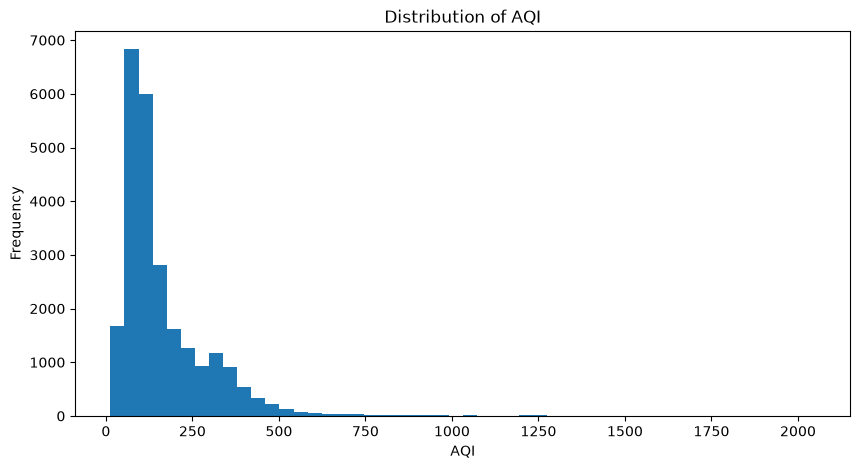

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["AQI"].dropna(), bins=50)
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.title("Distribution of AQI")
plt.show()

C:\Users\Durga Bhavani\AppData\Local\Temp\ipykernel_29384\328817840.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["AQI"].dropna(), vert=False)


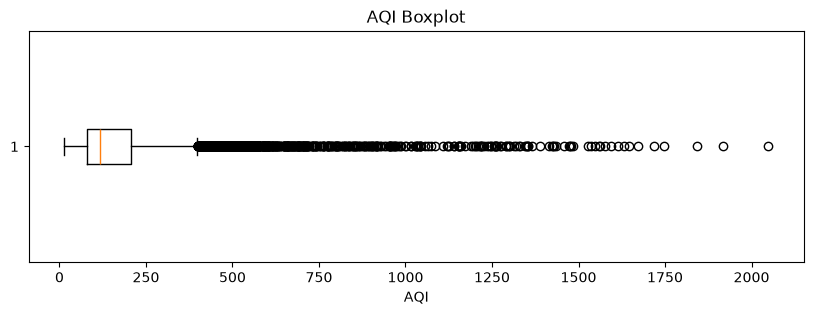

In [70]:
plt.figure(figsize=(10, 3))
plt.boxplot(df["AQI"].dropna(), vert=False)
plt.xlabel("AQI")
plt.title("AQI Boxplot")
plt.show()

In [71]:
correlation = df.select_dtypes(include="number").corr()["AQI"].sort_values(ascending=False)

print(correlation)

AQI        1.000000
PM10       0.803313
CO         0.683346
PM2.5      0.659181
NO2        0.537071
SO2        0.490586
NOx        0.486450
NO         0.452191
Toluene    0.279992
NH3        0.252019
O3         0.198991
Xylene     0.165532
Benzene    0.044407
Name: AQI, dtype: float64


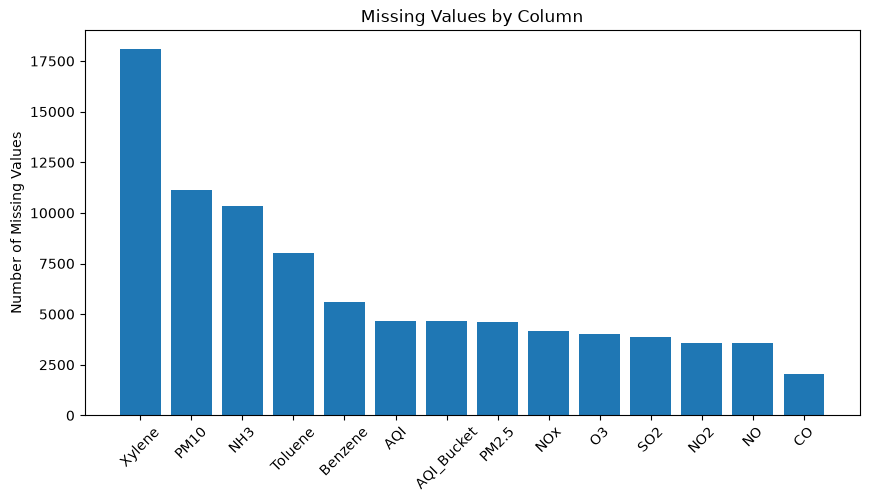

In [72]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(missing.index, missing.values)
plt.xticks(rotation=45)
plt.ylabel("Number of Missing Values")
plt.title("Missing Values by Column")
plt.show()

In [73]:
data = df.copy()

print("Original shape:", data.shape)

Original shape: (29531, 16)


In [74]:
data = data.dropna(subset=["AQI"])

print("Shape after removing missing AQI:", data.shape)

Shape after removing missing AQI: (24850, 16)


In [75]:
data = data.drop(columns=["AQI_Bucket"])

print(data.columns.tolist())

['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']


In [76]:
data["Date"] = pd.to_datetime(data["Date"])

data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Day"] = data["Date"].dt.day
data["DayOfWeek"] = data["Date"].dt.dayofweek

data = data.drop(columns=["Date"])

data.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Year,Month,Day,DayOfWeek
28,Ahmedabad,83.13,NaN,6.93,28.71,33.72,NaN,6.93,49.52,59.76,0.02,0.00,3.14,209.0,2015,1,29,3
29,Ahmedabad,79.84,NaN,13.85,28.68,41.08,NaN,13.85,48.49,97.07,0.04,0.00,4.81,328.0,2015,1,30,4
30,Ahmedabad,94.52,NaN,24.39,32.66,52.61,NaN,24.39,67.39,111.33,0.24,0.01,7.67,514.0,2015,1,31,5
31,Ahmedabad,135.99,NaN,43.48,42.08,84.57,NaN,43.48,75.23,102.70,0.40,0.04,25.87,782.0,2015,2,1,6
32,Ahmedabad,178.33,NaN,54.56,35.31,72.80,NaN,54.56,55.04,107.38,0.46,0.06,35.61,914.0,2015,2,2,0


In [77]:
data.isnull().sum()

City             0
PM2.5          678
PM10          7086
NO             387
NO2            391
NOx           1857
NH3           6536
CO             445
SO2            605
O3             807
Benzene       3535
Toluene       5826
Xylene       15372
AQI              0
Year             0
Month            0
Day              0
DayOfWeek        0
dtype: int64

In [78]:
print(data.shape)
print(data.columns.tolist())
data.isnull().sum()

(24850, 18)
['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'Year', 'Month', 'Day', 'DayOfWeek']


City             0
PM2.5          678
PM10          7086
NO             387
NO2            391
NOx           1857
NH3           6536
CO             445
SO2            605
O3             807
Benzene       3535
Toluene       5826
Xylene       15372
AQI              0
Year             0
Month            0
Day              0
DayOfWeek        0
dtype: int64

In [79]:
numeric_cols = data.select_dtypes(include="number").columns

print(numeric_cols.tolist())

['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'Year', 'Month', 'Day', 'DayOfWeek']


In [80]:
for col in numeric_cols:
    if col != "AQI":
        data[col] = data[col].fillna(data[col].median())

In [81]:
print(data.isnull().sum())

City         0
PM2.5        0
PM10         0
NO           0
NO2          0
NOx          0
NH3          0
CO           0
SO2          0
O3           0
Benzene      0
Toluene      0
Xylene       0
AQI          0
Year         0
Month        0
Day          0
DayOfWeek    0
dtype: int64


In [82]:
X = data.drop(columns=["AQI"])
y = data["AQI"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (24850, 17)
y shape: (24850,)


In [83]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Year', 'Month', 'Day', 'DayOfWeek']

Target:
AQI


In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (19880, 17)
Testing data: (4970, 17)


In [85]:
categorical_features = ["City"]

numerical_features = [
    "PM2.5", "PM10", "NO", "NO2", "NOx", "NH3",
    "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene",
    "Year", "Month", "Day", "DayOfWeek"
]

print("Categorical features:", categorical_features)
print("Number of numerical features:", len(numerical_features))

Categorical features: ['City']
Number of numerical features: 16


In [86]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("city", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numbers", "passthrough", numerical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [87]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [88]:
y_pred_linear = linear_model.predict(X_test)

print("First 10 actual AQI values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted AQI values:")
print(y_pred_linear[:10])

First 10 actual AQI values:
[141. 209. 111. 124.  81.  54.  74.  99.  97.  60.]

First 10 predicted AQI values:
[111.97019993 191.78261549 114.37838469 146.01965123  68.43428525
  67.83708826  70.34843822  89.74503827 132.95063923  78.12886149]


In [89]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Results
-------------------------
MAE : 29.967729728180668
MSE : 3214.070355251409
RMSE: 56.69277163141179
R²  : 0.824473450885265


In [90]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [91]:
y_pred_rf = random_forest_model.predict(X_test)

print("First 10 actual AQI values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted AQI values:")
print(y_pred_rf[:10])

First 10 actual AQI values:
[141. 209. 111. 124.  81.  54.  74.  99.  97.  60.]

First 10 predicted AQI values:
[110.41 206.43 103.43 140.37  78.28  63.38  64.34 104.16 135.61  60.04]


In [92]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
--------------------
MAE : 20.340422535211268
MSE : 1602.5603131589537
RMSE: 40.03199112158867
R²  : 0.9124811063773316


In [93]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ]
)

gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [94]:
y_pred_gb = gradient_boosting_model.predict(X_test)

print("First 10 actual AQI values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted AQI values:")
print(y_pred_gb[:10])

First 10 actual AQI values:
[141. 209. 111. 124.  81.  54.  74.  99.  97.  60.]

First 10 predicted AQI values:
[ 96.61874798 218.79353839 105.97485409 120.25530595  72.20853583
  61.75417673  64.99221884 102.44675723 123.87481934  65.40413492]


In [95]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("------------------------")
print("MAE :", mae_gb)
print("MSE :", mse_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting Results
------------------------
MAE : 23.20787306066441
MSE : 1898.6874802288066
RMSE: 43.57393120007428
R²  : 0.8963090335880823


In [96]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

xgboost_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgboost_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [97]:
y_pred_xgb = xgboost_model.predict(X_test)

print("First 10 actual AQI values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted AQI values:")
print(y_pred_xgb[:10])

First 10 actual AQI values:
[141. 209. 111. 124.  81.  54.  74.  99.  97.  60.]

First 10 predicted AQI values:
[102.83046 216.48866 100.61749 122.27162  80.04674  58.35569  64.86611
 103.02458 127.30906  68.88971]


In [98]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("---------------")
print("MAE :", mae_xgb)
print("MSE :", mse_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost Results
---------------
MAE : 20.659652590607735
MSE : 1767.1073206403155
RMSE: 42.036975636221925
R²  : 0.9034948785733354


In [99]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        mae_linear,
        mae_rf,
        mae_gb,
        mae_xgb
    ],
    "MSE": [
        mse_linear,
        mse_rf,
        mse_gb,
        mse_xgb
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf,
        rmse_gb,
        rmse_xgb
    ],
    "R2": [
        r2_linear,
        r2_rf,
        r2_gb,
        r2_xgb
    ]
})

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,29.967730,3214.070355,56.692772,0.824473
1,Random Forest,20.340423,1602.560313,40.031991,0.912481
2,Gradient Boosting,23.207873,1898.687480,43.573931,0.896309
3,XGBoost,20.659653,1767.107321,42.036976,0.903495


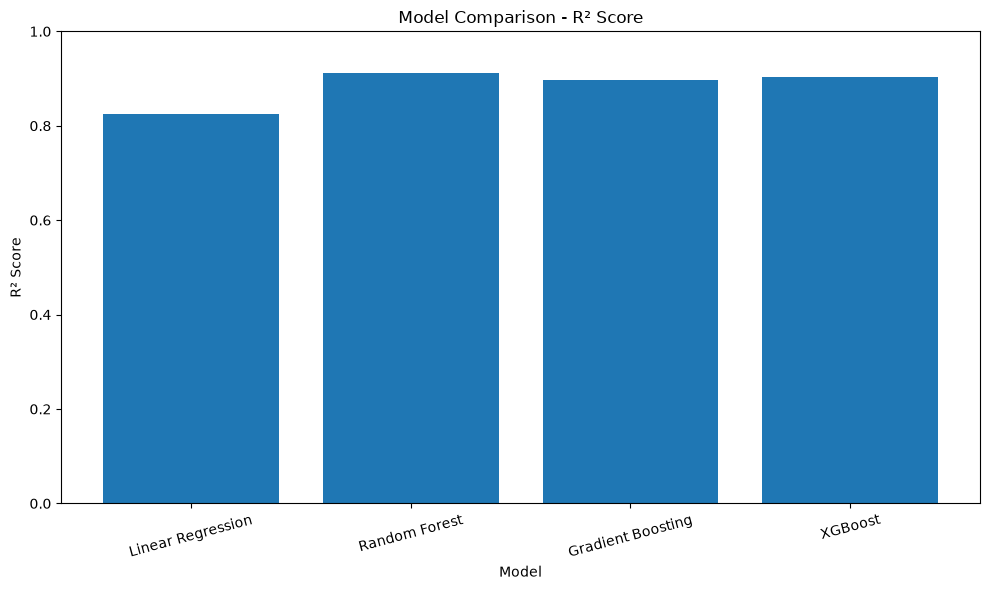

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(results["Model"], results["R2"])

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

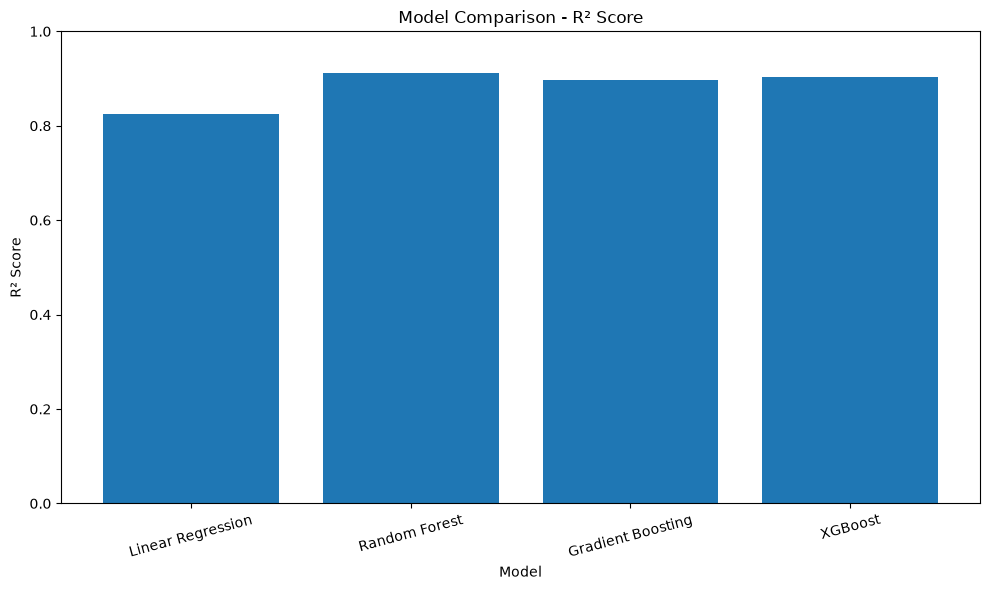

In [101]:
import os

os.makedirs("../plots", exist_ok=True)

plt.figure(figsize=(10, 6))
plt.bar(results["Model"], results["R2"])

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig("../plots/model_comparison_r2.png", dpi=300, bbox_inches="tight")
plt.show()

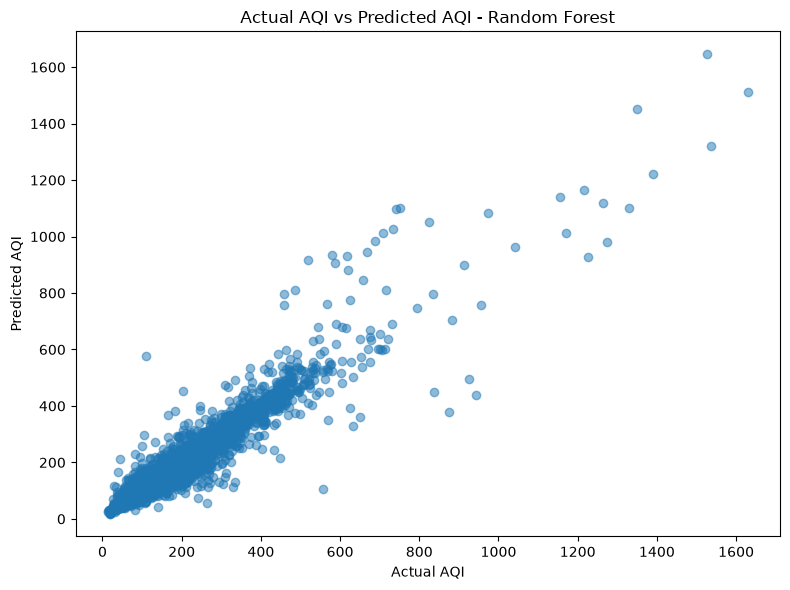

In [102]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual AQI vs Predicted AQI - Random Forest")

plt.tight_layout()
plt.show()

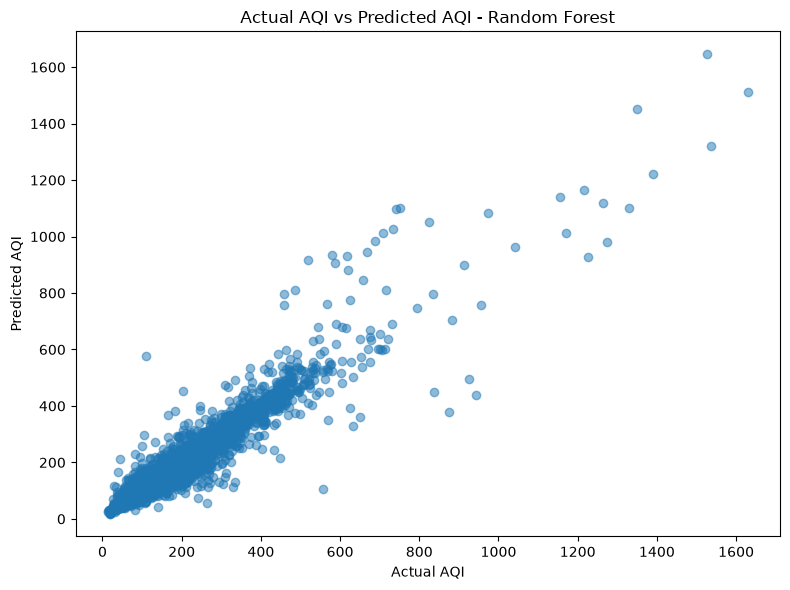

In [103]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual AQI vs Predicted AQI - Random Forest")

plt.tight_layout()

plt.savefig(
    "../plots/actual_vs_predicted_aqi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

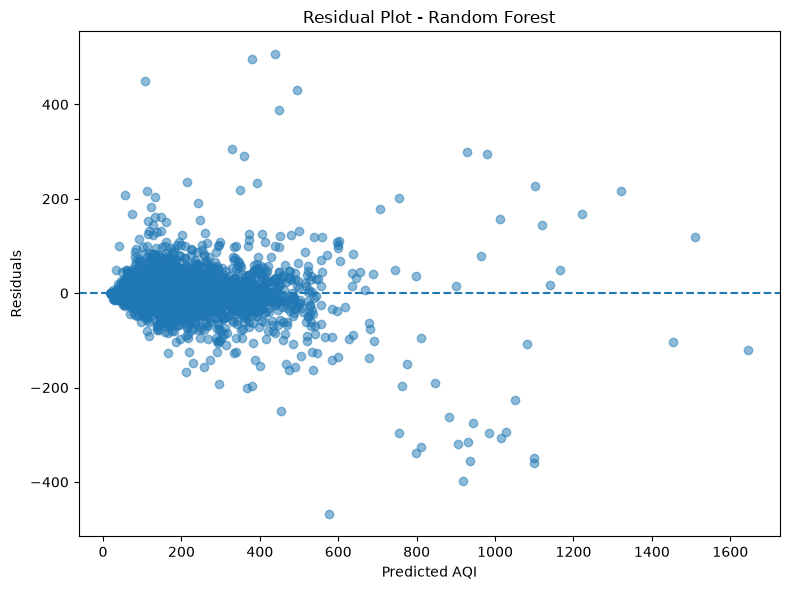

In [104]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_rf, residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted AQI")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")

plt.tight_layout()
plt.show()

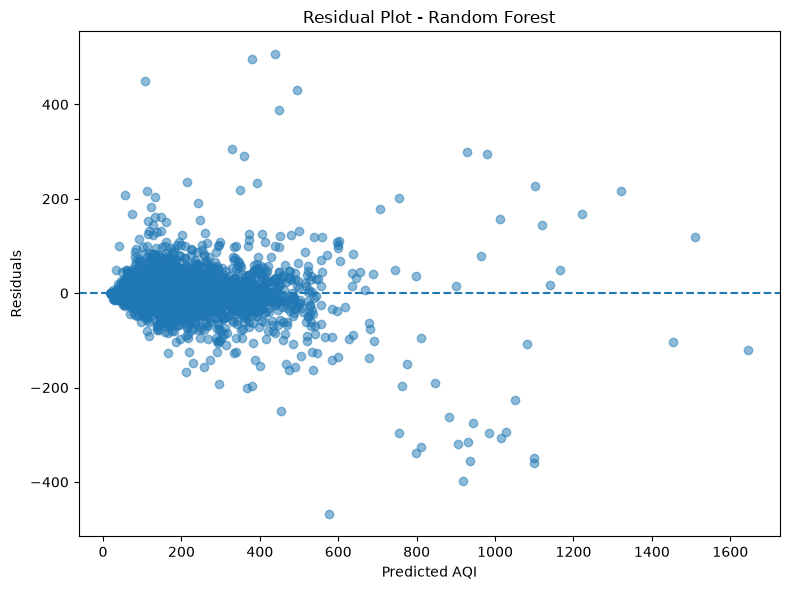

In [105]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred_rf, residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted AQI")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")

plt.tight_layout()

plt.savefig(
    "../plots/residual_plot_rf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

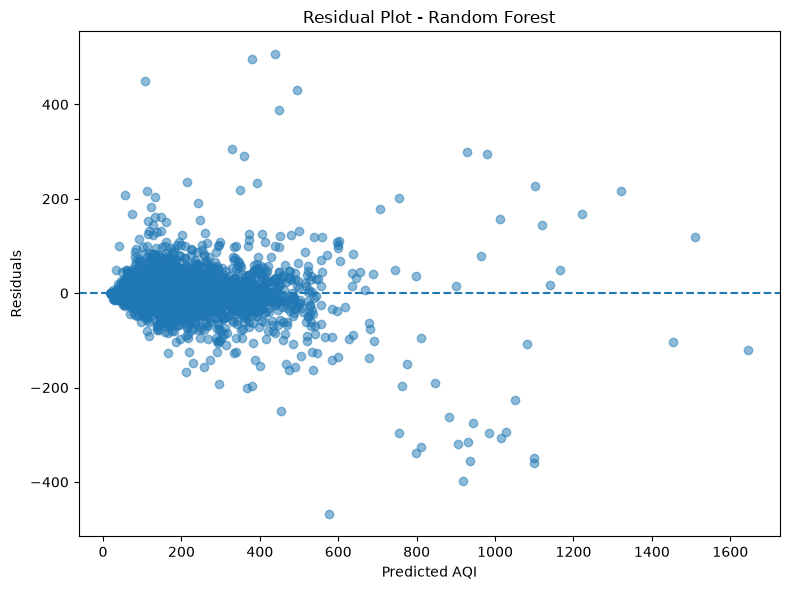

In [106]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred_rf, residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted AQI")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")

plt.tight_layout()

plt.savefig(
    "../plots/residual_plot_rf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [107]:
results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,29.967730,3214.070355,56.692772,0.824473
1,Random Forest,20.340423,1602.560313,40.031991,0.912481
2,Gradient Boosting,23.207873,1898.687480,43.573931,0.896309
3,XGBoost,20.659653,1767.107321,42.036976,0.903495


In [108]:
import os

os.makedirs("../models", exist_ok=True)

In [109]:
import joblib

joblib.dump(
    random_forest_model,
    "../models/random_forest_aqi_model.pkl"
)

['../models/random_forest_aqi_model.pkl']